In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
import math

In [ ]:
data = pd.read_csv('Daily_website_visitors.csv')

In [22]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2167 entries, 0 to 2166
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Row                2167 non-null   int64
 1   Day                2167 non-null   str  
 2   Day.Of.Week        2167 non-null   int64
 3   Date               2167 non-null   str  
 4   Page.Loads         2167 non-null   int64
 5   Unique.Visits      2167 non-null   int64
 6   First.Time.Visits  2167 non-null   int64
 7   Returning.Visits   2167 non-null   int64
dtypes: int64(6), str(2)
memory usage: 135.6 KB


In [3]:
data.sample(10)

,Row,Day,Day.Of.Week,Date,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits
436,437,Tuesday,3,11/24/2015,"5,879","4,140","3,475",665
5,6,Friday,6,9/19/2014,"2,815","1,863","1,622",241
777,778,Sunday,1,10/30/2016,"3,953","2,921","2,344",577
1968,1969,Monday,2,2/3/2020,"4,728","3,694","3,174",520
614,615,Friday,6,5/20/2016,"4,456","3,324","2,725",599
380,381,Tuesday,3,9/29/2015,"5,151","3,868","3,305",563
1270,1271,Wednesday,4,3/7/2018,"5,635","3,734","3,037",697
1139,1140,Friday,6,10/27/2017,"3,345","2,478","1,984",494
1638,1639,Sunday,1,3/10/2019,"4,099","2,898","2,397",501
1844,1845,Wednesday,4,10/2/2019,"5,143","3,683","3,209",474


In [21]:
for attr in ['Page.Loads', 'Unique.Visits', 'First.Time.Visits', 'Returning.Visits']:
    data[attr] = data[attr].str.replace(',', '', regex=False).astype(int)

In [5]:
data['Date'] = pd.to_datetime(data['Date'], format='%m/%d/%Y')

In [7]:
data.describe().round(2)

,Row,Day.Of.Week,Date,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits
count,2167.0,2167.0,2167,2167.00,2167.00,2167.00,2167.00
mean,1084.0,4.0,2017-09-01 00:00:00,4116.99,2943.65,2431.82,511.82
min,1.0,1.0,2014-09-14 00:00:00,1002.00,667.00,522.00,133.00
25%,542.5,2.0,2016-03-08 12:00:00,3114.50,2226.00,1830.00,388.50
50%,1084.0,4.0,2017-09-01 00:00:00,4106.00,2914.00,2400.00,509.00
75%,1625.5,6.0,2019-02-24 12:00:00,5020.50,3667.50,3038.00,626.50
max,2167.0,7.0,2020-08-19 00:00:00,7984.00,5541.00,4616.00,1036.00
std,625.7,2.0,NaN,1350.98,977.89,828.70,168.74


In [43]:
visits = data['Unique.Visits']

In [97]:
def pprint(test_result):
    for field, value in zip(test_result._fields, test_result):
        print(f'{field}: {value}')
        

## Check the basic statistics.

In [44]:
visits.describe()

count    2167.000000
mean     2943.646516
std       977.886472
min       667.000000
25%      2226.000000
50%      2914.000000
75%      3667.500000
max      5541.000000
Name: Unique.Visits, dtype: float64

In [45]:
stats.describe(visits)

DescribeResult(nobs=np.int64(2167), minmax=(np.int64(667), np.int64(5541)), mean=np.float64(2943.6465159206277), variance=np.float64(956261.952553645), skewness=np.float64(0.08546150845351878), kurtosis=np.float64(-0.5861101941515221))

In [46]:
names = ['mean', 'median', 'mode', 'std', 'skewness', 'kurtosis', 'min', 'max']
methods = [pd.Series.mean, pd.Series.median, pd.Series.mode, pd.Series.std, pd.Series.skew, pd.Series.kurtosis, pd.Series.min, pd.Series.max]

for name, method in zip(names, methods):
    print(name, ":", method(visits))

mean : 2943.6465159206277
median : 2914.0
mode : 0    1197
1    2667
2    2780
3    3039
Name: Unique.Visits, dtype: int64
std : 977.8864722214154
skewness : 0.08552071738277019
kurtosis : -0.5846908742670962
min : 667
max : 5541


In [47]:
print(f'Check the mode value counts: {visits.value_counts().loc[visits.mode()]}')

Check the mode value counts: Unique.Visits
1197    5
2667    5
2780    5
3039    5
Name: count, dtype: int64


In [72]:
kurtosis_test_result = stats.kurtosistest(visits)
pprint(kurtosis_test_result)

statistic: -8.00814267
pvalue: 0.0


### Summmary:
The data have a mean of 2943.65 and a median of 2914, with a standard deviation of 977.89, indicating substantial variability. The skewness of 0.086 is close to zero, suggesting the distribution is approximately symmetric. The negative kurtosis (−0.585) indicates a flatter distribution with lighter tails than a normal distribution, meaning relatively fewer extreme observations. The kurtosis test is statistically significant (p < 0.001), indicating that the distribution's kurtosis differs significantly from that of a normal distribution. Overall, the distribution is roughly symmetric but flatter and less heavy-tailed than a normal distribution.

## Grafical methods to summarixw a set of experimantal data

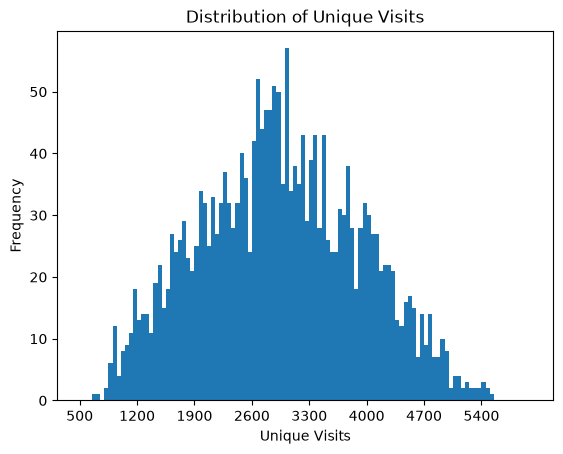

In [50]:
plt.hist(visits, bins=range(500, 6001, 50))
plt.xlabel('Unique Visits')
plt.ylabel('Frequency')
plt.title('Distribution of Unique Visits')
plt.xticks(range(500, 6001, 700))
plt.show()

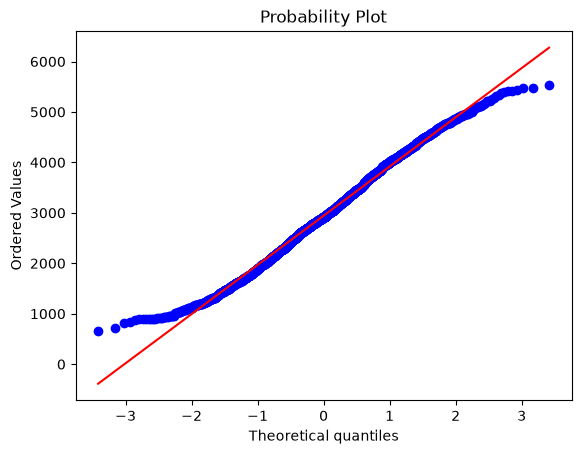

In [55]:
qq_plot = stats.probplot(visits, dist='norm', fit=True, plot=plt)
plt.show()

## Goodness-of-fit tests

#### Shapiro–Wilk test

In [98]:
shapiro_test = stats.shapiro(visits)
pprint(shapiro_test)


statistic: 0.9921118645085073
pvalue: 1.9272366144366718e-09


#### D'Agostino and Pearson's test.

In [99]:
normal_test = stats.normaltest(visits)
pprint(normal_test)

statistic: 66.77678687147275
pvalue: 3.159402600255041e-15


#### Anderson–Darling test

In [100]:
anderson_test = stats.anderson(visits, dist='norm')
pprint(anderson_test)

statistic: 2.7317527007862736
critical_values: [0.561 0.631 0.752 0.873 1.035]
significance_level: [15.  10.   5.   2.5  1. ]


/var/folders/49/bfzf3lk97t9fwjpw00k_1j5w0000gp/T/ipykernel_3194/2167313419.py:1: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  anderson_test = stats.anderson(visits, dist='norm')


#### Kolmogorov–Smirnov test

In [82]:
kolmogorov_smirnov_test = stats.kstest(visits, stats.norm.cdf, args=(visits.mean(), visits.std()))
pprint(kolmogorov_smirnov_test)

statistic: 0.02454206
pvalue: 0.14455451


| Test | Statistic | p-value / Result | Conclusion |
|---|---:|---|---|
| Shapiro-Wilk | 0.9921 | p ≈ 0.0000 | Reject normality |
| D’Agostino-Pearson | 66.7768 | p ≈ 0.0000 | Reject normality |
| Kolmogorov-Smirnov | 0.0245 | p = 0.1446* | Do not reject* |
| Anderson-Darling | 2.7318 | Critical value = 0.752 (5%) | Reject normality |

*The ordinary KS test isn't appropriate here because the normal distribution's mean and standard deviation were estimated from the same data.

### PSES p-390 Goodness-of-Fit Test

In [28]:
# p-392 battery lives p-43
mu = 3.5
sigma = 0.7

classes = [-math.inf, 2.95, 3.45, 3.95, math.inf]
f_obs = pd.array([7, 15, 10, 8])

# f_exp = pd.array([8.5, 10.3, 10.7, 10.5]) are taken from the normal distribution for class boundaries:

f_exp = []
for l, u in zip(classes, classes[1:]):
    f_exp.append(round((stats.norm(loc=mu, scale=sigma).cdf(u) - stats.norm(loc=mu, scale=sigma).cdf(l)) * sum(f_obs), 1))

# Now the sum of expected frequencies may not be equal to the total observations
print(sum(f_obs), sum(f_exp))


40 39.9


In [26]:
d = (sum(f_obs) - sum(f_exp)) / len(f_exp)
f_exp += d

In [27]:
stats.chisquare(f_obs=f_obs, f_exp=f_exp)

Power_divergenceResult(statistic=np.float64(3.1491474488660884), pvalue=np.float64(0.3691962922987155))